# 4 · RGB/HSV composites & unstructured meshes

`rgb_composite` / `hsv_composite` stack three bands; `tricontourf` / `tricontour` / `tripcolor` triangulate scattered/point data via `MeshGlyph`.

In [1]:
%matplotlib inline
from pathlib import Path

# Resolve the repo root so the bundled sample data is found whether this runs
# from docs/examples/ (mkdocs) or the repository root.
ROOT = Path.cwd()
while not (ROOT / "examples" / "data" / "acc4000.tif").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
RASTER = str(ROOT / "examples" / "data" / "acc4000.tif")
POINTS = str(ROOT / "tests" / "data" / "points.geojson")
print("data root:", ROOT)

data root: C:\gdrive\algorithms\Visualization\Digital-Earth


In [2]:
import numpy as np
from pyramids.dataset import Dataset
from digitalearth.scene import Map

ds = Dataset.read_file(RASTER)
base = np.nan_to_num(ds.read_array(band=0).astype('float32'))
rgb = Dataset.create_from_array(
    arr=np.stack([base, base * 0.5, base * 0.25]), geo=ds.geotransform, epsg=ds.epsg)
print('bands:', rgb.band_count)

2026-05-28 00:30:54 | INFO | pyramids.base.config | Logging is configured.


bands: 3


## RGB composite (band-first is handled internally)

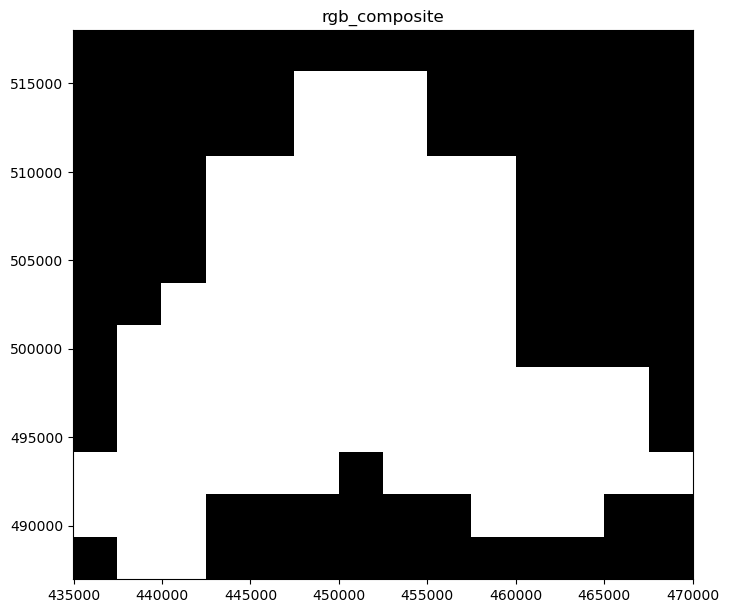

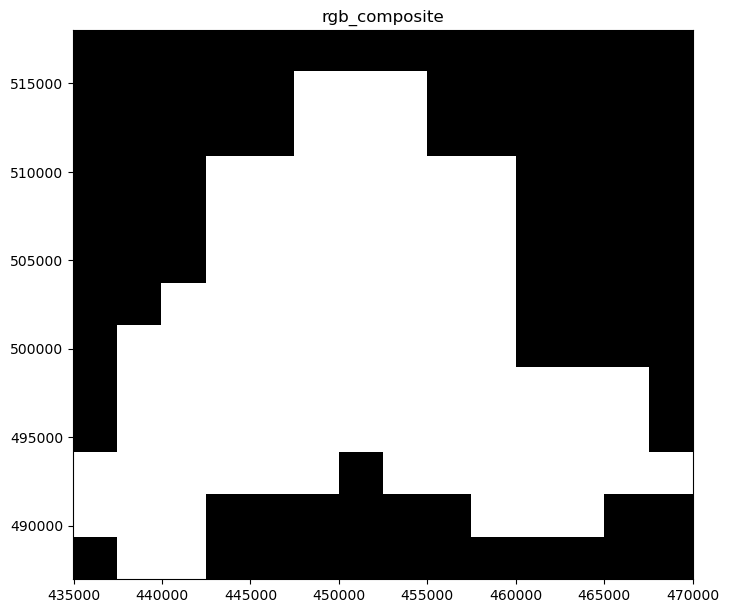

In [3]:
m = Map(crs=rgb.epsg)
m.rgb_composite(rgb)
m.set_title('rgb_composite')
m.fig

## HSV composite

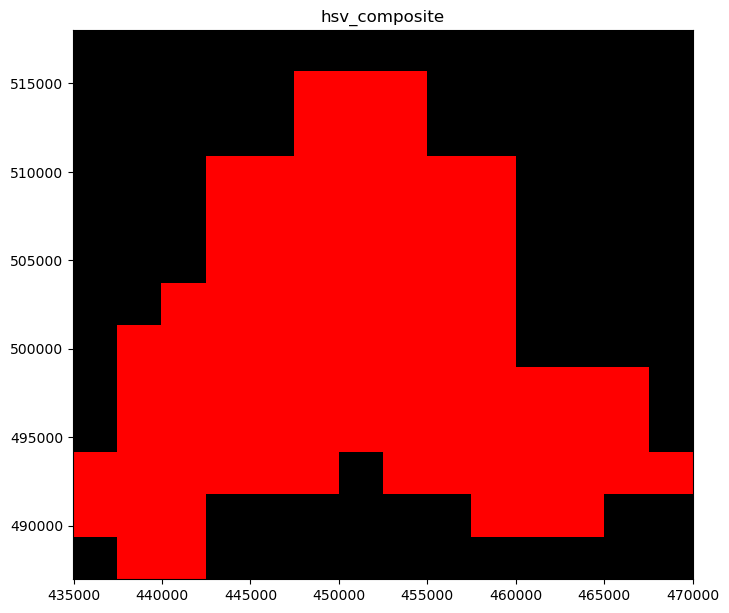

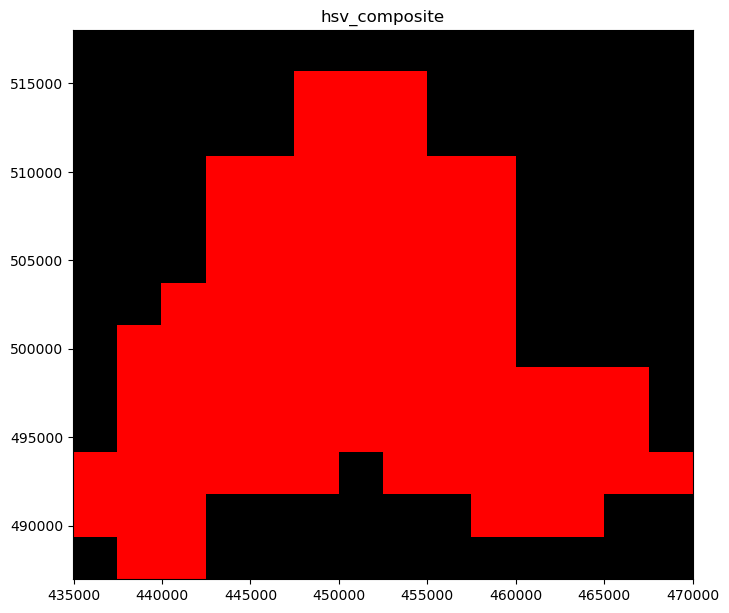

In [4]:
m = Map(crs=rgb.epsg)
m.hsv_composite(rgb)
m.set_title('hsv_composite')
m.fig

## Triangulated fields from raster cell centres

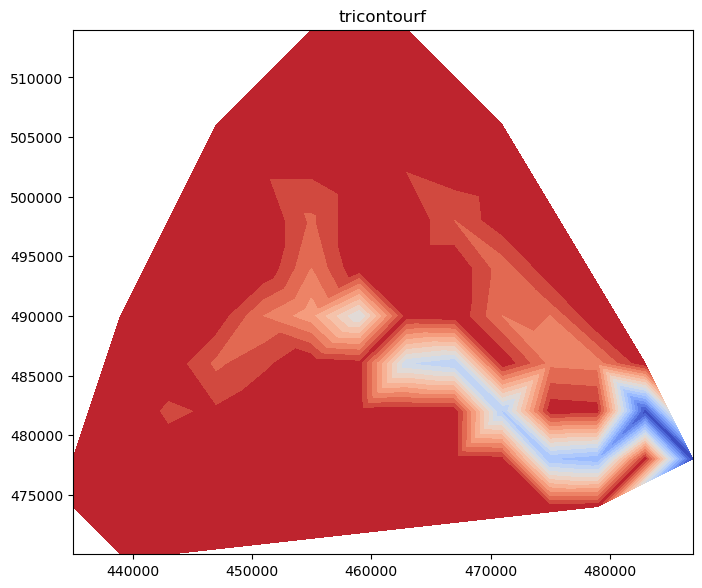

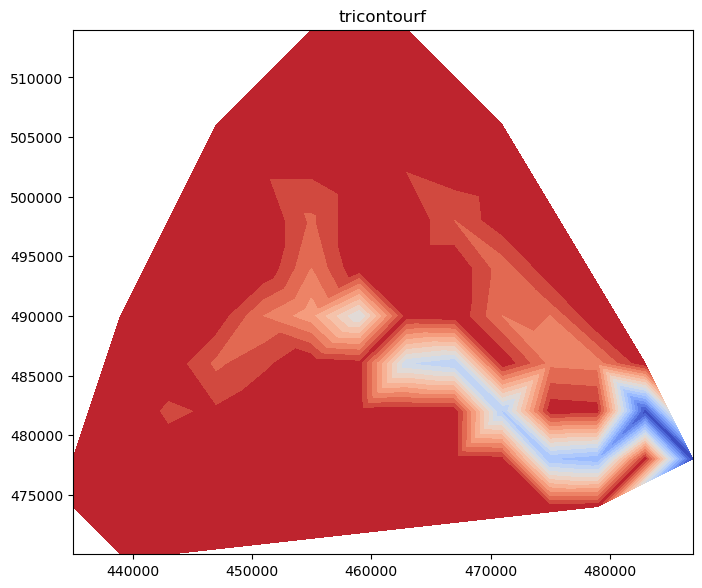

In [5]:
m = Map(crs=ds.epsg)
m.tricontourf(ds)
m.set_title('tricontourf')
m.fig

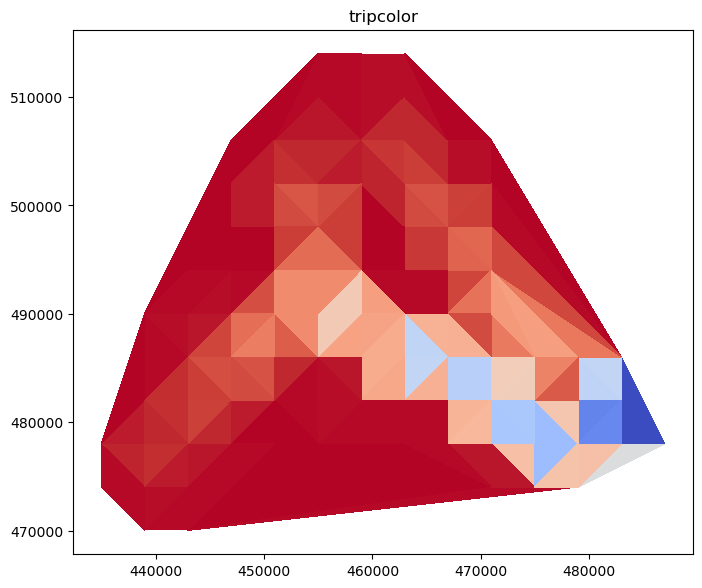

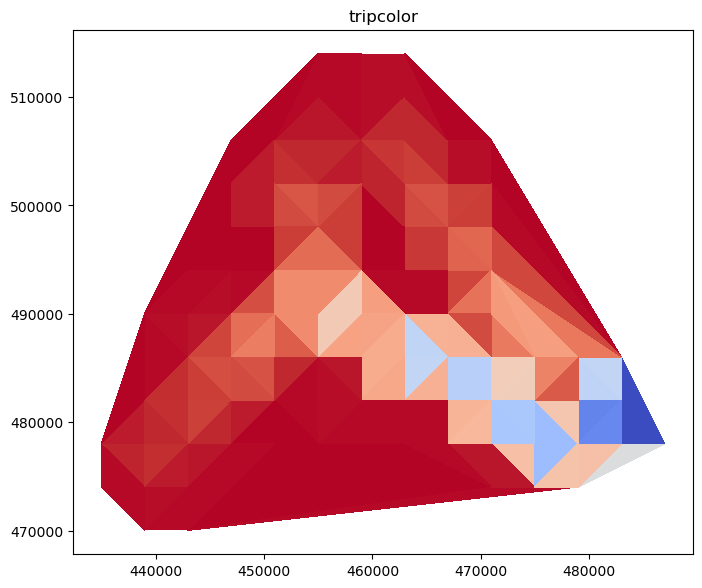

In [6]:
m = Map(crs=ds.epsg)
m.tripcolor(ds)
m.set_title('tripcolor')
m.fig